# Arduino Mega + Telemetry Radio — Text Communication Test

**A wireless UART link test between two Arduino Mega 2560 boards and two telemetry radios**

| | |
|---|---|
| Boards | 2 × Arduino Mega 2560 |
| Radios | 2 × serial (UART) telemetry radios, for example SiK 433 / 915 MHz drone telemetry radios |
| Arduino ↔ computer | `Serial` (USB) at **115200 baud** |
| Arduino ↔ radio | `Serial1` (TX1 = pin 18, RX1 = pin 19) at **57600 baud** |
| Sketches | `telemetry_sender`, `telemetry_receiver`, `telemetry_receiver_status` |

This notebook is the technical paper of the experiment. It explains the idea, the wiring, how UART
works, every part of the code, the test procedure, the expected results and the troubleshooting.
The Python cells produce the diagrams and small simulations; run them with
`pip install -r requirements.txt` and `jupyter notebook`.

### Contents
1. Project idea
2. System architecture
3. Components
4. The serial ports of the Arduino Mega 2560
5. How UART works (the 8N1 frame)
6. Wiring — TX always goes to RX
7. Two independent serial links and their baud rates
8. Configuring the telemetry radios
9. Sender sketch (Arduino #1)
10. Receiver sketch (Arduino #2)
11. Receiver with connection status — and the bug that was fixed
12. Message flow and round-trip time
13. Why a wrong baud rate produces garbage characters
14. Step-by-step test procedure
15. Expected results
16. Troubleshooting
17. Sending sensor data instead of words
18. How the code was verified
19. Safety and next steps
20. References

## 1. Project idea

The purpose of this experiment is to test **wireless communication between two Arduino Mega boards
using two telemetry radio modules**, before any drone hardware (Pixhawk, motors, ESCs) is connected.

* **Arduino Mega #1 is the SENDER.** The user types any word or sentence in the Arduino IDE Serial
  Monitor. The Arduino sends it to telemetry radio #1, which transmits it wirelessly.
* **Arduino Mega #2 is the RECEIVER.** Telemetry radio #2 receives the text and passes it to
  Arduino #2, which displays it in its own Serial Monitor.
* Arduino #2 then sends an **acknowledgement** (`ACK: <text>`) back to Arduino #1. When Arduino #1
  displays the ACK, communication is proven to work in **both directions**.

The experiment answers four questions:

| Test | Question |
|---|---|
| 1 | Can Arduino #1 send characters to telemetry radio #1? |
| 2 | Can telemetry radio #2 receive them over the air? |
| 3 | Can Arduino #2 read and display them? |
| 4 | Can Arduino #2 return an acknowledgement that Arduino #1 receives? |

In addition, the improved sender sketch **checks that the ACK text is identical to the text that was
sent** and prints the **round-trip time**, so the link quality can be judged automatically.

In [1]:
# Common setup for the diagrams of this notebook
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

os.makedirs("images", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "computer": "#e3ecf8",
    "arduino":  "#dcf1e2",
    "radio":    "#fde9cf",
    "message":  "#1f5fa8",
    "ack":      "#c0392b",
}


def box(ax, x, y, w, h, text, color, fontsize=10, bold=False):
    patch = FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                           boxstyle="round,pad=0.02,rounding_size=0.08",
                           fc=color, ec="#333333", lw=1.2)
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            fontweight="bold" if bold else "normal")


def arrow(ax, x1, y1, x2, y2, color="#333333", ls="-", lw=1.8):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=14, color=color, lw=lw, linestyle=ls))

print("Diagram helpers ready.")

Diagram helpers ready.


## 2. System architecture

```
Computer #1 --USB--> Arduino Mega #1 --UART--> Telemetry #1 ))) wireless ((( Telemetry #2 --UART--> Arduino Mega #2 --USB--> Computer #2
```

Each Arduino uses **two different serial links**: USB to its computer, and a UART to its radio.
The text travels from left to right (blue); the acknowledgement travels back from Arduino #2 to
Arduino #1 (red, dashed).

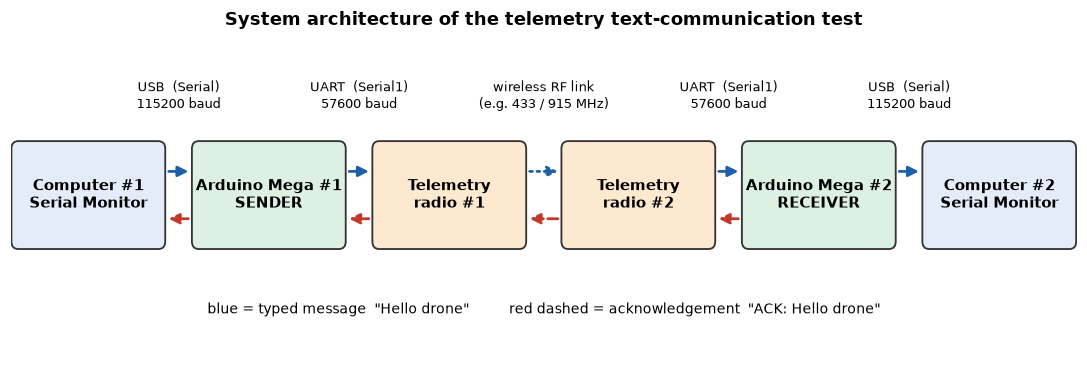

In [2]:
fig, ax = plt.subplots(figsize=(12.5, 3.8))
ax.set_xlim(0, 12.4)
ax.set_ylim(0.3, 3.7)
ax.axis("off")

nodes = [
    (0.9,  "Computer #1\nSerial Monitor",  COLORS["computer"]),
    (3.0,  "Arduino Mega #1\nSENDER",      COLORS["arduino"]),
    (5.1,  "Telemetry\nradio #1",           COLORS["radio"]),
    (7.3,  "Telemetry\nradio #2",           COLORS["radio"]),
    (9.4,  "Arduino Mega #2\nRECEIVER",    COLORS["arduino"]),
    (11.5, "Computer #2\nSerial Monitor",  COLORS["computer"]),
]
for x, text, color in nodes:
    box(ax, x, 2.0, 1.75, 1.1, text, color, fontsize=9.5, bold=True)

links = [
    (0.9, 3.0, "USB  (Serial)\n115200 baud", True),
    (3.0, 5.1, "UART  (Serial1)\n57600 baud", True),
    (5.1, 7.3, "wireless RF link\n(e.g. 433 / 915 MHz)", True),
    (7.3, 9.4, "UART  (Serial1)\n57600 baud", True),
    (9.4, 11.5, "USB  (Serial)\n115200 baud", False),
]
for a, b, label, has_ack in links:
    rf = "RF" in label
    arrow(ax, a + 0.9, 2.25, b - 0.9, 2.25, color=COLORS["message"], ls=":" if rf else "-")
    if has_ack:
        arrow(ax, b - 0.9, 1.75, a + 0.9, 1.75, color=COLORS["ack"], ls="--")
    ax.text((a + b) / 2, 3.05, label, ha="center", va="center", fontsize=8.5)

ax.text(6.2, 0.75, "blue = typed message  \"Hello drone\"          red dashed = acknowledgement  \"ACK: Hello drone\"",
        ha="center", fontsize=9)
ax.set_title("System architecture of the telemetry text-communication test", fontsize=12, fontweight="bold")
fig.savefig("images/system_architecture.png", bbox_inches="tight")
plt.show()

## 3. Components

| # | Component | Notes |
|---|---|---|
| 1 | Arduino Mega 2560 #1 | sender |
| 2 | Arduino Mega 2560 #2 | receiver |
| 3 | Telemetry radio #1 | UART radio (e.g. SiK 433/915 MHz, 57600 baud default) |
| 4 | Telemetry radio #2 | must be configured to talk to radio #1 (same frequency band, NETID, air speed …) |
| 5 | USB cable for Arduino #1 | power + Serial Monitor |
| 6 | USB cable for Arduino #2 | power + Serial Monitor |
| 7 | Jumper wires | TX, RX, GND and power for each radio |
| 8 | Computer(s) with Arduino IDE | one computer with two IDE windows, or two computers |
| 9 | Power source for each radio if needed | high-power radios may need their own 5 V supply |

> **Antennas:** always connect the antennas before powering a radio. Transmitting without an antenna
> can damage the radio's power amplifier.

## 4. The serial ports of the Arduino Mega 2560

The Mega 2560 has **four hardware UARTs**. Each one has its own transmit/receive hardware and a
64-byte receive buffer that is filled in the background by an interrupt.

| Port in code | TX pin | RX pin | Used in this project for |
|---|---|---|---|
| `Serial`  | 1  | 0  | USB connection to the computer (Serial Monitor) |
| `Serial1` | **18** | **19** | **telemetry radio** |
| `Serial2` | 16 | 17 | free |
| `Serial3` | 14 | 15 | free |

Because `Serial` is busy with the USB connection, the radio is connected to `Serial1`.

**Why hardware `Serial1` instead of `SoftwareSerial`?**
`SoftwareSerial` creates a UART in software: it blocks interrupts while it receives each byte,
cannot transmit and receive at the same time, and becomes unreliable at 57600 baud and above.
A hardware UART does all the bit timing itself, so the sketch can print to the Serial Monitor
while radio data keeps arriving.

## 5. How UART works (the 8N1 frame)

UART sends one byte as a **frame** of 10 bits (format **8N1**: 8 data bits, no parity, 1 stop bit):

* the line rests **HIGH** (idle),
* a **start bit** (LOW) announces a new byte,
* **8 data bits**, least-significant bit first,
* a **stop bit** (HIGH).

There is no clock wire. Both sides must agree on the **baud rate** (bits per second) in advance;
the receiver measures time from the falling edge of the start bit and samples every bit in its middle.

$$ t_\text{bit} = \frac{1}{\text{baud}} \qquad\qquad t_\text{byte} = \frac{10}{\text{baud}} $$

At 57600 baud one bit lasts 17.36 µs and one byte 173.6 µs. The plot shows the letter **`H`**
(ASCII 72 = `0x48` = `0b01001000`) on the TX line.

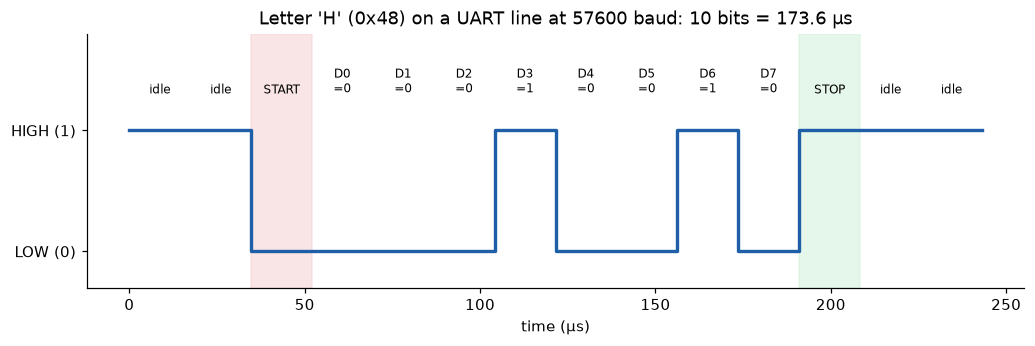

In [3]:
def uart_frame(byte):
    # start bit, 8 data bits (LSB first), stop bit
    return [0] + [(byte >> i) & 1 for i in range(8)] + [1]

baud = 57600
bit_us = 1e6 / baud
bits = [1, 1] + uart_frame(ord("H")) + [1, 1]
t = np.arange(len(bits) + 1) * bit_us

fig, ax = plt.subplots(figsize=(11, 3))
ax.step(t, bits + [bits[-1]], where="post", lw=2.2, color=COLORS["message"])

labels = ["idle", "idle", "START"] + [f"D{i}\n={b}" for i, b in enumerate(uart_frame(ord('H'))[1:9])] + ["STOP", "idle", "idle"]
for i, label in enumerate(labels):
    ax.text((i + 0.5) * bit_us, 1.28, label, ha="center", va="bottom", fontsize=8)
ax.axvspan(2 * bit_us, 3 * bit_us, color="#f6d5d5", alpha=0.6)
ax.axvspan(11 * bit_us, 12 * bit_us, color="#d5f0dc", alpha=0.6)

ax.set_ylim(-0.3, 1.8)
ax.set_yticks([0, 1])
ax.set_yticklabels(["LOW (0)", "HIGH (1)"])
ax.set_xlabel("time (µs)")
ax.set_title(f"Letter 'H' (0x48) on a UART line at {baud} baud: 10 bits = {10 * bit_us:.1f} µs")
fig.savefig("images/uart_frame.png", bbox_inches="tight")
plt.show()

## 6. Wiring — TX always goes to RX

A UART output (**TX**, transmit) must drive the input (**RX**, receive) of the other device.
The connections therefore **cross**:

| Telemetry radio | | Arduino Mega | Signal direction |
|---|---|---|---|
| TX  | → | **RX1 — pin 19** | radio → Arduino |
| RX  | ← | **TX1 — pin 18** | Arduino → radio |
| GND | — | GND | common reference (required) |
| 5V  | — | 5V  | power (see note) |

The wiring is **identical for both boards** (radio #1 → Mega #1, radio #2 → Mega #2).
Never connect TX → TX or RX → RX: two outputs would fight each other and nothing would be received.

**Electrical notes**

* **Supply voltage** — check that your radio is a 5 V module before connecting its power pin to 5V.
  SiK-type drone radios are normally powered from 5 V.
* **Current** — a 100 mW radio can be powered from the Arduino's 5V pin (USB-powered). High-power
  radios (for example 1 W modules) can draw more current than the Arduino should supply: use a
  separate 5 V supply and connect its GND to the Arduino GND.
* **Logic level** — many radios use 3.3 V logic on TX/RX. Their 3.3 V TX output is normally read
  correctly by the 5 V Mega. The Mega's 5 V TX output must only go to a radio RX input that is
  5 V tolerant (true for common SiK radios — check the datasheet, otherwise use a level shifter).
* **CTS/RTS** — flow-control pins, if present, are left unconnected (hardware flow control is off by default).

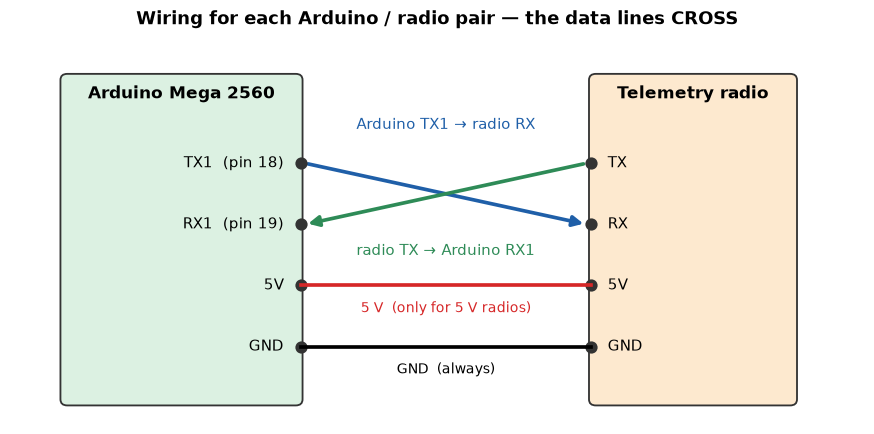

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.set_xlim(0, 10)
ax.set_ylim(0.2, 5.3)
ax.axis("off")

box(ax, 2.0, 2.6, 2.8, 4.3, "", COLORS["arduino"])
box(ax, 8.0, 2.6, 2.4, 4.3, "", COLORS["radio"])
ax.text(2.0, 4.45, "Arduino Mega 2560", ha="center", fontweight="bold", fontsize=11)
ax.text(8.0, 4.45, "Telemetry radio", ha="center", fontweight="bold", fontsize=11)

arduino_pins = {"TX1  (pin 18)": 3.6, "RX1  (pin 19)": 2.8, "5V": 2.0, "GND": 1.2}
radio_pins   = {"TX": 3.6, "RX": 2.8, "5V": 2.0, "GND": 1.2}

for name, y in arduino_pins.items():
    ax.plot(3.4, y, "o", color="#333333", ms=7)
    ax.text(3.2, y, name, ha="right", va="center", fontsize=10)
for name, y in radio_pins.items():
    ax.plot(6.8, y, "o", color="#333333", ms=7)
    ax.text(7.0, y, name, ha="left", va="center", fontsize=10)

# Crossed data lines
arrow(ax, 3.45, 3.6, 6.75, 2.8, color="#1f5fa8", lw=2.4)   # Arduino TX1 -> radio RX
arrow(ax, 6.75, 3.6, 3.45, 2.8, color="#2e8b57", lw=2.4)   # radio TX -> Arduino RX1
ax.plot([3.4, 6.8], [2.0, 2.0], color="#d62728", lw=2.4)    # 5V
ax.plot([3.4, 6.8], [1.2, 1.2], color="black", lw=2.4)      # GND

ax.text(5.1, 4.05, "Arduino TX1 → radio RX", color="#1f5fa8", ha="center", fontsize=9.5)
ax.text(5.1, 2.4, "radio TX → Arduino RX1", color="#2e8b57", ha="center", fontsize=9.5)
ax.text(5.1, 1.65, "5 V  (only for 5 V radios)", color="#d62728", ha="center", fontsize=9)
ax.text(5.1, 0.85, "GND  (always)", ha="center", fontsize=9)
ax.set_title("Wiring for each Arduino / radio pair — the data lines CROSS", fontsize=12, fontweight="bold")
fig.savefig("images/wiring_telemetry.png", bbox_inches="tight")
plt.show()

## 7. Two independent serial links and their baud rates

| Link | Code | Baud rate | Must match |
|---|---|---|---|
| Arduino ↔ computer | `Serial.begin(115200);` | 115200 | the baud rate selected in the Serial Monitor |
| Arduino ↔ radio | `Serial1.begin(TELEMETRY_BAUD);` | 57600 | the **serial speed configured inside the radio** |

The two links are completely independent: `Serial.println("Hello")` prints on the computer,
`Serial1.println("Hello")` sends the text out of pin 18 to the radio.

Many drone telemetry radios use **57600** baud, but they can be configured for 9600, 19200, 38400,
57600, 115200 … If your radios use another value, change

```cpp
#define TELEMETRY_BAUD 57600
```

in **both** sketches. The table shows how long the example message takes on the wire at each speed:

In [5]:
message = "Hello drone\r\n"          # println() adds "\r\n"
ack = "ACK: Hello drone\r\n"

print(f"{'baud':>7} | {'bit time':>9} | {'byte time':>9} | {'max bytes/s':>11} | {'message 13 B':>12} | {'ACK 18 B':>9}")
print("-" * 72)
for baud in [9600, 19200, 38400, 57600, 115200]:
    byte_time = 10 / baud
    print(f"{baud:>7} | {1e6 / baud:>6.2f} µs | {byte_time * 1e6:>6.1f} µs | {baud / 10:>11.0f} | "
          f"{len(message) * byte_time * 1e3:>9.2f} ms | {len(ack) * byte_time * 1e3:>6.2f} ms")

   baud |  bit time | byte time | max bytes/s | message 13 B |  ACK 18 B
------------------------------------------------------------------------
   9600 | 104.17 µs | 1041.7 µs |         960 |     13.54 ms |  18.75 ms
  19200 |  52.08 µs |  520.8 µs |        1920 |      6.77 ms |   9.38 ms
  38400 |  26.04 µs |  260.4 µs |        3840 |      3.39 ms |   4.69 ms
  57600 |  17.36 µs |  173.6 µs |        5760 |      2.26 ms |   3.12 ms
 115200 |   8.68 µs |   86.8 µs |       11520 |      1.13 ms |   1.56 ms


## 8. Configuring the telemetry radios

The two radios must be configured to talk to each other. For the common **SiK firmware** radios
(3DR / Holybro / RFD900 style drone telemetry) the parameters can be read and changed with
**Mission Planner** (*Initial Setup → Optional Hardware → SiK Radio*, "Load Settings" / "Save Settings")
or with AT commands.

| Parameter | Meaning | Rule |
|---|---|---|
| `SERIAL_SPEED` | UART speed to the Arduino (`57` = 57600) | must equal `TELEMETRY_BAUD` of the Arduino connected to that radio |
| `AIR_SPEED` | over-the-air data rate (kbit/s) | same on both radios |
| `NETID` | network ID | same on both radios |
| `MIN_FREQ`, `MAX_FREQ`, `NUM_CHANNELS` | frequency-hopping band | same on both radios |
| `ECC` | error-correcting code | same on both radios |
| `MAVLINK` | 0 = raw data, 1 = MAVLink framing, 2 = low latency | 0 (raw) is ideal for plain text; 1 also passes text |
| `TXPOWER` | transmit power | legal limit for your country |

**AT commands** (Serial Monitor at the radio's baud, "No line ending" for `+++`):
wait 1 s, send `+++` and wait 1 s → the radio answers `OK`; `ATI5` lists the parameters,
`ATS1=57` sets `SERIAL_SPEED`, `AT&W` saves, `ATZ` restarts. `RT…` commands address the remote radio.

**Status LEDs of SiK radios**

| LED | Meaning |
|---|---|
| green blinking | searching for the other radio |
| green solid | **radio link established** |
| red flashing | transmitting data |
| red solid | firmware update mode |

> The solid green LED is the radios' own "connected" indicator. The Arduino itself only sees
> characters on the UART; it has no connection-status signal (see section 11).

## 9. Sender sketch (Arduino #1)

File: [`telemetry_sender/telemetry_sender.ino`](telemetry_sender/telemetry_sender.ino)

**Job of the sender**
1. Wait for the user to type something in the Serial Monitor.
2. Read the text.
3. Send the text through `Serial1` to the radio.
4. Show `[SENT] …` as confirmation.
5. Listen for the reply of Arduino #2 and show `[RECEIVER REPLY] …`.
6. **Check** that the reply is exactly `ACK: <sent text>` → `[LINK OK]` with the round-trip time.
7. If no reply arrives within 3 s → `[NO ACK]` with hints about the return path.

```cpp
/*
  ===================================================
     ARDUINO MEGA + TELEMETRY TEXT SENDER
  ===================================================

  Board   : Arduino Mega 2560  #1  (SENDER)
  Project : Telemetry radio text-communication test

  WIRING  (the UART lines must CROSS: TX -> RX, RX <- TX)
    Telemetry TX   -> Arduino RX1  (pin 19)
    Telemetry RX   <- Arduino TX1  (pin 18)
    Telemetry GND  -> Arduino GND
    Telemetry 5V   -> Arduino 5V   (only if your radio is a 5 V module)

  SERIAL PORTS
    Serial   (USB)           -> computer / Serial Monitor, 115200 baud
    Serial1  (pins 18 / 19)  -> telemetry radio, TELEMETRY_BAUD

  SERIAL MONITOR SETTINGS
    Baud rate   : 115200
    Line ending : Newline

  HOW IT WORKS
    1. Type any word or sentence in the Serial Monitor and press ENTER.
    2. The text is sent to telemetry radio #1 through Serial1.
    3. Arduino Mega #2 (receiver) answers with "ACK: <your text>".
    4. This sketch prints the reply, checks that it matches the text
       that was sent, and shows the round-trip time.
    5. If no reply arrives within ACK_TIMEOUT_MS a warning is printed,
       which means the RETURN path (receiver -> sender) has a problem.
*/


// ---------------------------------------------------
// CONFIGURATION
// ---------------------------------------------------

// Must match the serial speed configured inside the telemetry radio
// (many drone telemetry radios use 57600). Use the SAME value on both
// Arduino boards.
#define TELEMETRY_BAUD 57600

// Speed of the USB link between the Arduino and the computer.
#define USB_BAUD 115200

// How long to wait for the "ACK: ..." reply before printing a warning.
const unsigned long ACK_TIMEOUT_MS = 3000;


// ---------------------------------------------------
// VARIABLES
// ---------------------------------------------------

String message = "";           // text typed by the user
String lastSentMessage = "";   // last text sent, waiting for its ACK

unsigned long sendTime = 0;    // millis() when the last text was sent
bool waitingForAck = false;    // true while an ACK is expected

unsigned long messagesSent = 0;
unsigned long acksReceived = 0;


// ---------------------------------------------------
// SETUP
// ---------------------------------------------------

void setup()
{
  // Communication with the computer
  Serial.begin(USB_BAUD);

  // Communication with the telemetry radio
  Serial1.begin(TELEMETRY_BAUD);

  delay(1000);

  Serial.println();
  Serial.println(F("================================================"));
  Serial.println(F("        TELEMETRY SENDER READY"));
  Serial.println(F("================================================"));
  Serial.println();
  Serial.print(F("USB baud       : "));
  Serial.println(USB_BAUD);
  Serial.print(F("Telemetry baud : "));
  Serial.println(TELEMETRY_BAUD);
  Serial.println();
  Serial.println(F("Type any word or sentence."));
  Serial.println(F("Then press ENTER."));
  Serial.println();
}


// ---------------------------------------------------
// LOOP
// ---------------------------------------------------

void loop()
{
  // -----------------------------------------------
  // 1) Check if the user typed something
  // -----------------------------------------------

  if (Serial.available())
  {
    // Read the text until the ENTER / newline character
    message = Serial.readStringUntil('\n');

    // Remove spaces and the '\r' character at the ends
    message.trim();

    // Only send if the message is not empty
    if (message.length() > 0)
    {
      // Send through telemetry (println adds "\r\n" = end of message)
      Serial1.println(message);

      lastSentMessage = message;
      sendTime = millis();
      waitingForAck = true;
      messagesSent++;

      // Show locally
      Serial.print(F("[SENT] "));
      Serial.println(message);
    }
  }


  // -----------------------------------------------
  // 2) Check if the receiver sent anything back
  // -----------------------------------------------

  if (Serial1.available())
  {
    String reply = Serial1.readStringUntil('\n');

    reply.trim();

    if (reply.length() > 0)
    {
      Serial.print(F("[RECEIVER REPLY] "));
      Serial.println(reply);

      // The receiver answers with "ACK: " + the text it received.
      String expectedAck = String("ACK: ") + lastSentMessage;

      if (waitingForAck && reply == expectedAck)
      {
        waitingForAck = false;
        acksReceived++;

        Serial.print(F("[LINK OK] ACK matches the sent text. Round-trip time = "));
        Serial.print(millis() - sendTime);
        Serial.print(F(" ms  ("));
        Serial.print(acksReceived);
        Serial.print(F(" of "));
        Serial.print(messagesSent);
        Serial.println(F(" messages acknowledged)"));
      }
      else if (reply.startsWith("ACK:"))
      {
        Serial.println(F("[WARNING] This ACK does not match the last text sent."));
        Serial.println(F("          Possible data corruption (check baud rate),"));
        Serial.println(F("          or several messages were sent very quickly."));
      }
    }
  }


  // -----------------------------------------------
  // 3) No ACK received in time?
  // -----------------------------------------------

  if (waitingForAck && (millis() - sendTime > ACK_TIMEOUT_MS))
  {
    waitingForAck = false;

    Serial.print(F("[NO ACK] No reply received within "));
    Serial.print(ACK_TIMEOUT_MS);
    Serial.println(F(" ms."));
    Serial.println(F("         If Arduino #2 displayed the message, the forward path works"));
    Serial.println(F("         but the RETURN path does not. Check:"));
    Serial.println(F("         - Arduino #2 TX1 (pin 18) -> Telemetry #2 RX"));
    Serial.println(F("         - Telemetry #1 TX -> Arduino #1 RX1 (pin 19)"));
  }
}
```

### How the sender code works

| Code | Explanation |
|---|---|
| `Serial.available()` | number of characters waiting from the Serial Monitor. Non-zero → the user pressed ENTER. |
| `Serial.readStringUntil('\n')` | reads the typed text up to the newline sent by the Serial Monitor (line ending = **Newline**). If no newline arrives it returns after the default 1 s timeout. |
| `message.trim()` | removes spaces and the `'\r'` that appears with the "Both NL & CR" setting. |
| `Serial1.println(message)` | sends the text **plus `"\r\n"`** out of TX1 (pin 18). The newline tells the receiver that the message is complete. |
| `lastSentMessage`, `sendTime`, `waitingForAck` | remember what was sent and when, to verify the answer. |
| `reply == expectedAck` | the reply must be exactly `"ACK: " + lastSentMessage`. Any corrupted character is detected. |
| `millis() - sendTime` | round-trip time: Arduino #1 → radio → radio → Arduino #2 → radio → radio → Arduino #1. |
| `ACK_TIMEOUT_MS` | after 3000 ms without ACK the sender reports `[NO ACK]`. |

Example: typing `Hello` makes `message` contain `Hello`; `Serial1.println(message)` puts the 7 bytes
`H e l l o \r \n` on the TX1 pin, and the radio transmits them.

## 10. Receiver sketch (Arduino #2)

File: [`telemetry_receiver/telemetry_receiver.ino`](telemetry_receiver/telemetry_receiver.ino)

**Job of the receiver**
1. Monitor `Serial1`.
2. Wait for telemetry data.
3. Read the complete message (up to the newline).
4. Display it (`TELEMETRY CONNECTED / DATA RECEIVED`, `MESSAGE: …`).
5. Send `ACK: <message>` back to Arduino #1.

```cpp
/*
  ===================================================
     ARDUINO MEGA + TELEMETRY TEXT RECEIVER
  ===================================================

  Board   : Arduino Mega 2560  #2  (RECEIVER)
  Project : Telemetry radio text-communication test

  WIRING  (the UART lines must CROSS: TX -> RX, RX <- TX)
    Telemetry TX   -> Arduino RX1  (pin 19)
    Telemetry RX   <- Arduino TX1  (pin 18)
    Telemetry GND  -> Arduino GND
    Telemetry 5V   -> Arduino 5V   (only if your radio is a 5 V module)

  SERIAL PORTS
    Serial   (USB)           -> computer / Serial Monitor, 115200 baud
    Serial1  (pins 18 / 19)  -> telemetry radio, TELEMETRY_BAUD

  HOW IT WORKS
    1. Wait for text arriving from telemetry radio #2 (Serial1).
    2. Read the complete line (up to the newline character).
    3. Display the message in the Serial Monitor.
    4. Send "ACK: <message>" back to Arduino #1, which proves that
       communication works in BOTH directions.
*/


// ---------------------------------------------------
// CONFIGURATION
// ---------------------------------------------------

// Must match the serial speed configured inside the telemetry radio.
// Use the SAME value as in the sender sketch.
#define TELEMETRY_BAUD 57600

// Speed of the USB link between the Arduino and the computer.
#define USB_BAUD 115200


// ---------------------------------------------------
// VARIABLES
// ---------------------------------------------------

String receivedMessage = "";

unsigned long messageCount = 0;


// ---------------------------------------------------
// SETUP
// ---------------------------------------------------

void setup()
{
  // Communication with the computer
  Serial.begin(USB_BAUD);

  // Communication with the telemetry radio
  Serial1.begin(TELEMETRY_BAUD);

  delay(1000);

  Serial.println();
  Serial.println(F("================================================"));
  Serial.println(F("        TELEMETRY RECEIVER READY"));
  Serial.println(F("================================================"));
  Serial.println();
  Serial.print(F("USB baud       : "));
  Serial.println(USB_BAUD);
  Serial.print(F("Telemetry baud : "));
  Serial.println(TELEMETRY_BAUD);
  Serial.println();
  Serial.println(F("Waiting for telemetry messages..."));
  Serial.println();
}


// ---------------------------------------------------
// LOOP
// ---------------------------------------------------

void loop()
{
  // Check for incoming telemetry data
  if (Serial1.available())
  {
    // Read the complete line sent by the sender
    receivedMessage = Serial1.readStringUntil('\n');

    // Remove the '\r' character and spaces at the ends
    receivedMessage.trim();

    if (receivedMessage.length() > 0)
    {
      messageCount++;

      Serial.println();
      Serial.println(F("------------------------------------------------"));
      Serial.println(F("TELEMETRY CONNECTED / DATA RECEIVED"));
      Serial.print(F("MESSAGE: "));
      Serial.println(receivedMessage);
      Serial.print(F("Messages received: "));
      Serial.println(messageCount);
      Serial.println(F("------------------------------------------------"));

      // Send the acknowledgement back to the sender.
      // An incoming "ACK: ..." is never acknowledged again; this avoids
      // an endless "ACK: ACK: ACK: ..." loop if both boards were
      // accidentally programmed with a receiver sketch.
      if (!receivedMessage.startsWith("ACK:"))
      {
        Serial1.print(F("ACK: "));
        Serial1.println(receivedMessage);
      }
    }
  }
}
```

| Code | Explanation |
|---|---|
| `Serial1.available()` | "is data arriving from the telemetry radio?" |
| `Serial1.readStringUntil('\n')` | reads the complete line sent by the sender's `println()` |
| `receivedMessage.trim()` | removes the `'\r'` of `"\r\n"` |
| `Serial1.print("ACK: "); Serial1.println(receivedMessage);` | sends the acknowledgement back through the radios |
| `if (!receivedMessage.startsWith("ACK:"))` | never acknowledges an acknowledgement — prevents an endless `ACK: ACK: ACK: …` loop if both boards were accidentally programmed with a receiver sketch |

`TELEMETRY CONNECTED / DATA RECEIVED` means **data successfully arrived**. That proves that
Arduino #1, radio #1, the wireless link, radio #2 and Arduino #2 all work.

## 11. Receiver with connection status — and the bug that was fixed

File: [`telemetry_receiver_status/telemetry_receiver_status.ino`](telemetry_receiver_status/telemetry_receiver_status.ino)

The radios do not give the Arduino a "connected" signal, so this version defines the link as
**active if a message arrived recently**. If no message arrives for 5 s it prints
`STATUS: NO RECENT TELEMETRY DATA`, once; when messages return it prints `STATUS: DATA RESUMED`.

### The bug in the first version

The first draft contained this code:

```cpp
if (millis() - lastMessageTime > CONNECTION_TIMEOUT)
{
  static bool alreadyPrinted = false;     // variable A
  if (!alreadyPrinted) { ...print...; alreadyPrinted = true; }
}
else
{
  static bool alreadyPrinted = false;     // variable B  (a DIFFERENT variable!)
  alreadyPrinted = false;
}
```

A `static` variable belongs to the **block** in which it is declared. The two `alreadyPrinted`
variables have the same name but are two separate variables. The `else` branch resets variable B,
which nobody reads, so variable A stays `true` forever: **the timeout message is printed only for
the first outage, never again**. The compiler even warns: `variable 'alreadyPrinted' set but not used`.

### The fix

One variable at file scope, reset when a message arrives:

```cpp
bool timeoutReported = false;          // ONE shared flag

// when a message arrives:
timeoutReported = false;

// timeout check:
if (dataReceivedOnce && !timeoutReported && (millis() - lastMessageTime > CONNECTION_TIMEOUT))
{
  Serial.println(F("STATUS: NO RECENT TELEMETRY DATA"));
  timeoutReported = true;
}
```

The simulation below runs both versions with messages at 2, 3, 20, 21 and 40 s:

first version : 'NO RECENT TELEMETRY DATA' printed at t = [8.01] s
fixed version : 'NO RECENT TELEMETRY DATA' printed at t = [8.01, 26.01, 45.01] s


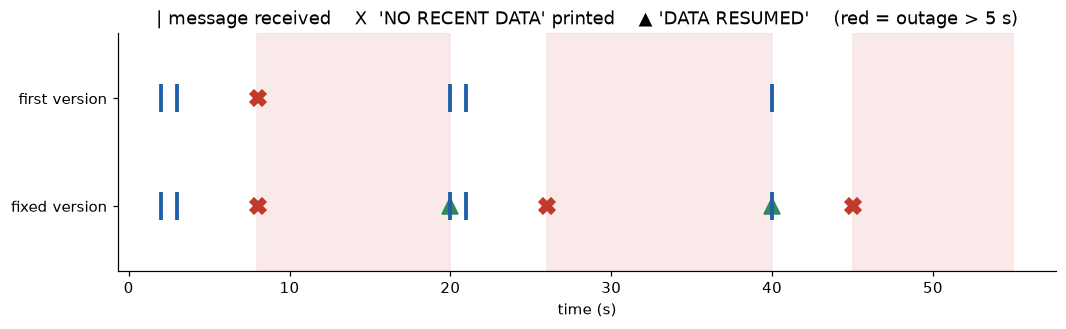

In [6]:
def simulate_status(original, message_times, t_end=55.0, timeout=5.0, dt=0.01):
    events = []
    last = 0.0
    received_once = False
    printed_a = False      # original: 'static' inside the if-branch
    printed_b = False      # original: 'static' inside the else-branch (never read)
    reported = False       # fixed version: one shared flag
    pending = sorted(message_times)

    for step in range(int(t_end / dt) + 1):
        t = step * dt
        if pending and t >= pending[0]:
            pending.pop(0)
            if not original and reported:
                events.append((t, "DATA RESUMED"))
            last, received_once, reported = t, True, False
            events.append((t, "DATA RECEIVED"))

        if original:
            if last > 0:
                if t - last > timeout:
                    if not printed_a:
                        events.append((t, "NO RECENT DATA"))
                        printed_a = True
                else:
                    printed_b = False
        elif received_once and not reported and t - last > timeout:
            events.append((t, "NO RECENT DATA"))
            reported = True
    return events

messages = [2, 3, 20, 21, 40]
fig, ax = plt.subplots(figsize=(11, 2.8))
for row, (name, original) in enumerate([("first version", True), ("fixed version", False)]):
    y = 1 - row
    events = simulate_status(original, messages)
    for t, kind in events:
        if kind == "DATA RECEIVED":
            ax.plot(t, y, "|", ms=18, mew=2.5, color=COLORS["message"])
        elif kind == "NO RECENT DATA":
            ax.plot(t, y, "X", ms=11, color=COLORS["ack"])
        else:
            ax.plot(t, y, "^", ms=10, color="#2e8b57")
    timeouts = [round(t, 2) for t, k in events if k == "NO RECENT DATA"]
    print(f"{name:14s}: 'NO RECENT TELEMETRY DATA' printed at t = {timeouts} s")

for start, end in [(8, 20), (26, 40), (45, 55)]:
    ax.axvspan(start, end, color="#f6d5d5", alpha=0.5)
ax.set_yticks([1, 0])
ax.set_yticklabels(["first version", "fixed version"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("time (s)")
ax.set_title("| message received    X  'NO RECENT DATA' printed    ▲ 'DATA RESUMED'    (red = outage > 5 s)")
fig.savefig("images/status_timeout_bug.png", bbox_inches="tight")
plt.show()

The first version reports only the first outage; the fixed version reports **every** outage and
the recovery.

> **Note:** the sender only transmits when somebody types. The status receiver therefore also
> prints "NO RECENT TELEMETRY DATA" when nobody types for 5 s. For a continuous link monitor the
> sender could transmit a short heartbeat line every second (see *Next steps*).

The complete fixed sketch:

```cpp
/*
  =====================================================
     TELEMETRY RECEIVER WITH CONNECTION STATUS
  =====================================================

  Board   : Arduino Mega 2560  #2  (RECEIVER)
  Project : Telemetry radio text-communication test

  Same job as telemetry_receiver.ino, plus a simple link status:

    STATUS: CONNECTED / DATA RECEIVED
        printed every time a message arrives.

    STATUS: NO RECENT TELEMETRY DATA
        printed ONCE when no message has arrived for
        CONNECTION_TIMEOUT milliseconds.

    STATUS: DATA RESUMED
        printed when messages arrive again after a timeout.

  NOTE
    Telemetry radios do not give the Arduino a "connected" signal.
    "Connected" here means "a message arrived recently". The sender only
    transmits when you type something, so the timeout message also
    appears if nobody types for CONNECTION_TIMEOUT milliseconds.

  WIRING  (the UART lines must CROSS: TX -> RX, RX <- TX)
    Telemetry TX   -> Arduino RX1  (pin 19)
    Telemetry RX   <- Arduino TX1  (pin 18)
    Telemetry GND  -> Arduino GND
    Telemetry 5V   -> Arduino 5V   (only if your radio is a 5 V module)

  Serial Monitor : 115200 baud
*/


// ---------------------------------------------------
// CONFIGURATION
// ---------------------------------------------------

#define TELEMETRY_BAUD 57600
#define USB_BAUD 115200

// Time without data after which "NO RECENT TELEMETRY DATA" is printed
const unsigned long CONNECTION_TIMEOUT = 5000;


// ---------------------------------------------------
// VARIABLES
// ---------------------------------------------------

String receivedMessage = "";

unsigned long lastMessageTime = 0;
unsigned long messageCount = 0;

// true after the first message has been received
bool dataReceivedOnce = false;

// ONE flag, shared by the "timeout" and the "data received" code.
// It makes sure the timeout message is printed only once per outage
// and is printed again for every new outage.
bool timeoutReported = false;


// ---------------------------------------------------
// SETUP
// ---------------------------------------------------

void setup()
{
  Serial.begin(USB_BAUD);

  Serial1.begin(TELEMETRY_BAUD);

  delay(1000);

  Serial.println();
  Serial.println(F("============================================"));
  Serial.println(F("   TELEMETRY RECEIVER STARTED"));
  Serial.println(F("============================================"));
  Serial.println();
  Serial.print(F("Telemetry baud     : "));
  Serial.println(TELEMETRY_BAUD);
  Serial.print(F("No-data timeout    : "));
  Serial.print(CONNECTION_TIMEOUT);
  Serial.println(F(" ms"));
  Serial.println();
  Serial.println(F("Waiting for telemetry messages..."));
}


// ---------------------------------------------------
// LOOP
// ---------------------------------------------------

void loop()
{
  // ------------------------------------
  // Receive message
  // ------------------------------------

  if (Serial1.available())
  {
    receivedMessage = Serial1.readStringUntil('\n');

    receivedMessage.trim();

    if (receivedMessage.length() > 0)
    {
      // Data is back after a reported timeout
      if (timeoutReported)
      {
        Serial.println();
        Serial.print(F("STATUS: DATA RESUMED after "));
        Serial.print((millis() - lastMessageTime) / 1000.0, 1);
        Serial.println(F(" s without data"));
      }

      lastMessageTime = millis();
      dataReceivedOnce = true;
      timeoutReported = false;
      messageCount++;

      Serial.println();
      Serial.println(F("============================================"));
      Serial.println(F("STATUS: CONNECTED / DATA RECEIVED"));
      Serial.print(F("MESSAGE: "));
      Serial.println(receivedMessage);
      Serial.print(F("Messages received: "));
      Serial.println(messageCount);
      Serial.println(F("============================================"));

      // Send acknowledgement (never acknowledge an ACK)
      if (!receivedMessage.startsWith("ACK:"))
      {
        Serial1.print(F("ACK: "));
        Serial1.println(receivedMessage);
      }
    }
  }


  // ------------------------------------
  // Connection timeout
  // ------------------------------------

  if (dataReceivedOnce &&
      !timeoutReported &&
      (millis() - lastMessageTime > CONNECTION_TIMEOUT))
  {
    Serial.println();
    Serial.println(F("STATUS: NO RECENT TELEMETRY DATA"));
    Serial.print(F("        (no message for more than "));
    Serial.print(CONNECTION_TIMEOUT / 1000.0, 1);
    Serial.println(F(" s)"));

    timeoutReported = true;
  }
}
```

## 12. Message flow and round-trip time

```
USER → Arduino #1 → Telemetry #1 → WIRELESS → Telemetry #2 → Arduino #2
                                                                   │  displays the message
Arduino #1 ← Telemetry #1 ← WIRELESS ← Telemetry #2 ← ─ ─ ─ ─ ─ ─ ┘  sends "ACK: …"
```

If Arduino #1 receives the ACK, **both the TX direction and the RX direction work**. The sender prints
the measured **round-trip time**. The diagram shows where that time is spent; the UART times are
exact, the radio latency is an **example value** (it depends on the radio's air speed, error
correction and packet settings — measure the real value with the sender sketch).

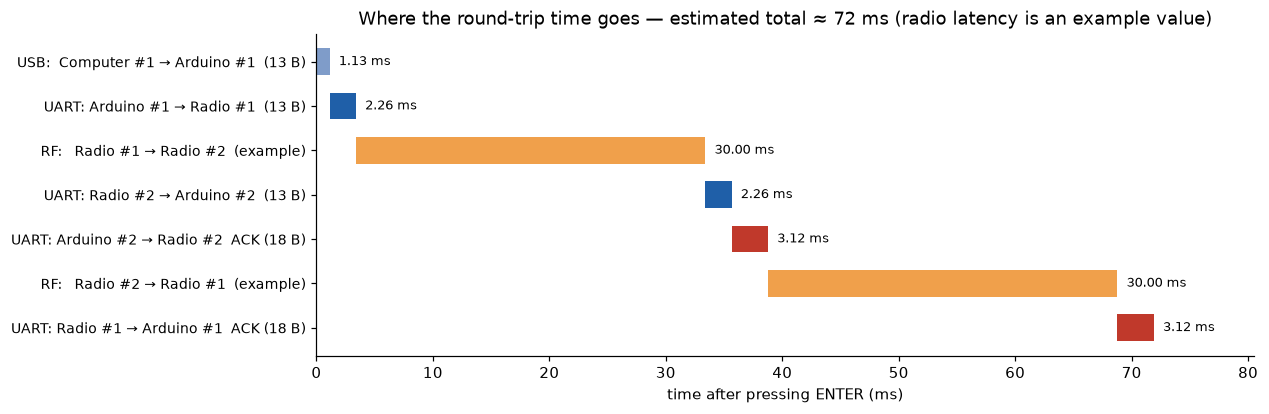

UART + USB time:  11.9 ms
radio latency  :  60.0 ms  (example)
round trip     :  71.9 ms


In [7]:
radio_latency_ms = 30.0                 # example value for one wireless hop
uart_ms = lambda nbytes, baud: nbytes * 10 / baud * 1000

steps = [
    ("USB:  Computer #1 → Arduino #1  (13 B)",      uart_ms(13, 115200), "#7f9cc9"),
    ("UART: Arduino #1 → Radio #1  (13 B)",         uart_ms(13, 57600),  COLORS["message"]),
    ("RF:   Radio #1 → Radio #2  (example)",        radio_latency_ms,    "#f0a04b"),
    ("UART: Radio #2 → Arduino #2  (13 B)",         uart_ms(13, 57600),  COLORS["message"]),
    ("UART: Arduino #2 → Radio #2  ACK (18 B)",     uart_ms(18, 57600),  COLORS["ack"]),
    ("RF:   Radio #2 → Radio #1  (example)",        radio_latency_ms,    "#f0a04b"),
    ("UART: Radio #1 → Arduino #1  ACK (18 B)",     uart_ms(18, 57600),  COLORS["ack"]),
]

fig, ax = plt.subplots(figsize=(11, 3.8))
t = 0.0
for row, (label, duration, color) in enumerate(steps):
    ax.barh(row, max(duration, 0.4), left=t, color=color, height=0.6)
    ax.text(t + duration + 0.8, row, f"{duration:.2f} ms", va="center", fontsize=8.5)
    t += duration

ax.set_yticks(range(len(steps)))
ax.set_yticklabels([label for label, _, _ in steps], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, t * 1.12)
ax.set_xlabel("time after pressing ENTER (ms)")
ax.set_title(f"Where the round-trip time goes — estimated total ≈ {t:.0f} ms "
             f"(radio latency is an example value)")
fig.savefig("images/message_timeline.png", bbox_inches="tight")
plt.show()

print(f"UART + USB time: {t - 2 * radio_latency_ms:5.1f} ms")
print(f"radio latency  : {2 * radio_latency_ms:5.1f} ms  (example)")
print(f"round trip     : {t:5.1f} ms")

## 13. Why a wrong baud rate produces garbage characters

If you send `Hello` but receive something like `H%l▒o` or random symbols, the most common reason is a
**baud-rate mismatch**: the receiver samples the bits at the wrong moments. The cell below simulates a
UART receiver: the text `Hello` is transmitted at one baud rate and decoded at another.

In [8]:
def uart_bits(data, idle_bits=3):
    bits = [1] * idle_bits
    for byte in data:
        bits += [0] + [(byte >> i) & 1 for i in range(8)] + [1]
    return bits + [1] * idle_bits


def uart_receive(tx_bits, tx_baud, rx_baud):
    # Simple UART receiver: wait for a falling edge, sample each bit in its middle
    duration = len(tx_bits) / tx_baud
    level = lambda t: tx_bits[min(int(t * tx_baud), len(tx_bits) - 1)]
    received, t, step = [], 0.0, 1 / (tx_baud * 64)
    while t < duration:
        if level(t) == 1:
            t += step
            continue
        middle = t + 0.5 / rx_baud
        if middle >= duration or level(middle) != 0:
            t += step
            continue
        value = sum(level(middle + (i + 1) / rx_baud) << i for i in range(8))
        stop_ok = level(middle + 9 / rx_baud) == 1
        received.append((value, stop_ok))
        t = middle + 9 / rx_baud
        while t < duration and level(t) == 0:
            t += step
    return received


def printable(value):
    return chr(value) if 32 <= value < 127 else "▒"


for tx_baud, rx_baud in [(57600, 57600), (115200, 57600), (57600, 115200), (9600, 57600)]:
    result = uart_receive(uart_bits(b"Hello"), tx_baud, rx_baud)
    text = "".join(printable(v) for v, _ in result)
    errors = sum(not ok for _, ok in result)
    verdict = "OK" if text == "Hello" else "GARBAGE"
    print(f"sent at {tx_baud:>6}, read at {rx_baud:>6}:  {text!r:22}  {len(result):2d} bytes, "
          f"{errors} framing errors  -> {verdict}")

sent at  57600, read at  57600:  'Hello'                  5 bytes, 0 framing errors  -> OK
sent at 115200, read at  57600:  '▒▒'                     2 bytes, 0 framing errors  -> GARBAGE
sent at  57600, read at 115200:  '▒▒f▒▒▒▒▒▒'              9 bytes, 2 framing errors  -> GARBAGE
sent at   9600, read at  57600:  '▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒'      16 bytes, 5 framing errors  -> GARBAGE


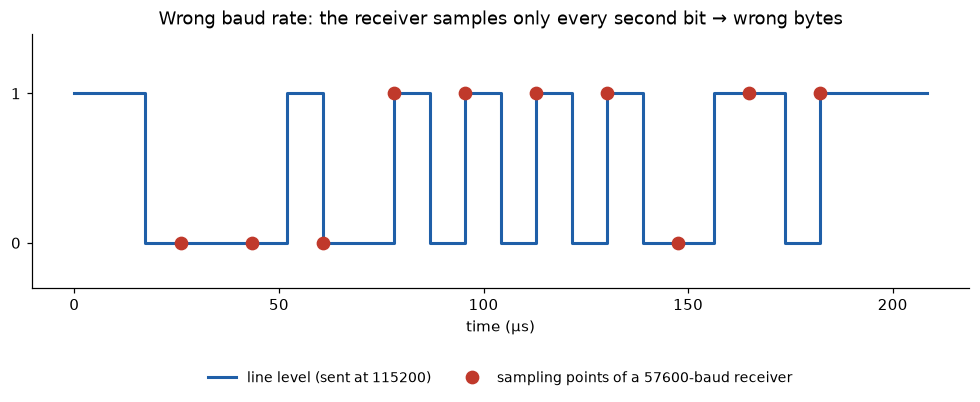

In [9]:
# Visualise one mismatch: 'H' sent at 115200 baud, receiver set to 57600 baud
tx_baud, rx_baud = 115200, 57600
bits = uart_bits(b"He", idle_bits=2)
t_us = np.arange(len(bits) + 1) / tx_baud * 1e6

fig, ax = plt.subplots(figsize=(11, 3))
ax.step(t_us, bits + [1], where="post", lw=2, color=COLORS["message"], label="line level (sent at 115200)")
start = 2 / tx_baud
samples = [start + (0.5 + i) / rx_baud for i in range(10)]
ax.plot(np.array(samples) * 1e6, [bits[min(int(s * tx_baud), len(bits) - 1)] for s in samples],
        "o", color=COLORS["ack"], ms=8, label="sampling points of a 57600-baud receiver")
ax.set_yticks([0, 1])
ax.set_ylim(-0.3, 1.4)
ax.set_xlabel("time (µs)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, fontsize=9, frameon=False)
ax.set_title("Wrong baud rate: the receiver samples only every second bit → wrong bytes")
fig.savefig("images/baud_mismatch.png", bbox_inches="tight")
plt.show()

## 14. Step-by-step test procedure

| Step | Action |
|---|---|
| 1 | Use only Arduino Mega #1, radio #1, radio #2, Arduino Mega #2. **Do not connect the Pixhawk, motors or ESCs.** |
| 2 | Connect radio #1 to Mega #1: radio TX → RX1 (19), radio RX → TX1 (18), GND → GND, power. |
| 3 | Connect radio #2 to Mega #2 the same way. |
| 4 | Connect both Arduino boards to the computer(s) with USB. |
| 5 | Upload `telemetry_sender.ino` to Arduino #1 (Tools → Board: *Arduino Mega or Mega 2560*, select its port). |
| 6 | Upload `telemetry_receiver.ino` (or `telemetry_receiver_status.ino`) to Arduino #2. |
| 7 | Open the Serial Monitor of the sender: **115200 baud**, line ending **Newline**. |
| 8 | Open the Serial Monitor of the receiver: **115200 baud**. |
| 9 | Type `Hello` into the sender's Serial Monitor. |
| 10 | Press ENTER. |
| 11 | Arduino #1 shows `[SENT] Hello`. |
| 12 | Arduino #2 shows `MESSAGE: Hello`. |
| 13 | Arduino #1 shows `[RECEIVER REPLY] ACK: Hello` and `[LINK OK] … Round-trip time = … ms`. |

If steps 11, 12 and 13 all happen, the communication system works correctly in both directions.

**Two Serial Monitors on one computer:** in Arduino IDE 2 open a second IDE window
(*File → New Sketch*), select the other board's port there and open its Serial Monitor.
Opening a Serial Monitor resets the Mega — this is normal.

**Why "Newline"?** The sender reads with `readStringUntil('\n')`; the newline tells the Arduino
that the message is complete. With "No line ending" the text is still sent, but only after a 1 s timeout.

## 15. Expected results

The following transcripts were produced by the **host simulation** in [`tests/`](../tests)
(the real sketch code running on a PC with a simulated radio link of 40 ms per direction).
On real hardware the round-trip time depends on your radios.

**Sender — Serial Monitor of Arduino #1**
```text
================================================
        TELEMETRY SENDER READY
================================================

USB baud       : 115200
Telemetry baud : 57600

Type any word or sentence.
Then press ENTER.

[SENT] Hello drone
[RECEIVER REPLY] ACK: Hello drone
[LINK OK] ACK matches the sent text. Round-trip time = 82 ms  (1 of 1 messages acknowledged)
```

**Receiver — Serial Monitor of Arduino #2**
```text
------------------------------------------------
TELEMETRY CONNECTED / DATA RECEIVED
MESSAGE: Hello drone
Messages received: 1
------------------------------------------------
```

**Sender when the return path is broken** (receiver shows the message, no ACK comes back)
```text
[SENT] Hello
[NO ACK] No reply received within 3000 ms.
         If Arduino #2 displayed the message, the forward path works
         but the RETURN path does not. Check:
         - Arduino #2 TX1 (pin 18) -> Telemetry #2 RX
         - Telemetry #1 TX -> Arduino #1 RX1 (pin 19)
```

**Receiver with status** (one message, a pause, a second message, another pause)
```text
STATUS: CONNECTED / DATA RECEIVED
MESSAGE: Hello
Messages received: 1

STATUS: NO RECENT TELEMETRY DATA
        (no message for more than 5.0 s)

STATUS: DATA RESUMED after 21.5 s without data

STATUS: CONNECTED / DATA RECEIVED
MESSAGE: Second message
Messages received: 2

STATUS: NO RECENT TELEMETRY DATA
        (no message for more than 5.0 s)
```

## 16. Troubleshooting

| Symptom | Likely cause | What to check |
|---|---|---|
| Arduino #2 receives nothing | radios not powered | power LED on both radios |
| | radios not linked | green LED **solid** on both radios; same NETID / frequency / air speed (section 8) |
| | TX/RX not crossed | radio TX → Arduino RX1 (19), radio RX → Arduino TX1 (18) |
| | no common ground | radio GND ↔ Arduino GND |
| | wrong baud rate | `TELEMETRY_BAUD` equal to the radio's `SERIAL_SPEED` on **both** boards |
| Random characters such as `H%l▒o` | baud-rate mismatch | section 13 — change `TELEMETRY_BAUD` on both boards |
| Serial Monitor shows garbage | Serial Monitor baud wrong | set 115200 in the Serial Monitor |
| Nothing is sent when pressing ENTER | empty line | type some text; empty lines are ignored |
| Text is sent only after 1 s | line ending "No line ending" | select **Newline** |
| Receiver shows the message but sender prints `[NO ACK]` | **return path** broken | Arduino #2 TX1 (18) → radio #2 RX, radio #1 TX → Arduino #1 RX1 (19) |
| `[WARNING] This ACK does not match…` | corrupted characters | baud rate, loose wires, radio settings, or messages typed very quickly |
| Works on the bench, not at distance | RF range | antennas attached and vertical, `TXPOWER`, obstacles, radios too close (< 1 m can saturate) |

## 17. Sending sensor data instead of words

The telemetry system simply transfers characters, so any text works:

```text
Hello
Drone test
Roll = 5 degrees
Battery = 12.4 V
Mission started
Emergency stop
```

Later the sender can transmit measurements in a `KEY=value` format, for example
`ROLL=5.4,PITCH=-2.1,YAW=43.8`, and the receiver can split and convert them. Python version:

In [10]:
line = "ROLL=5.4,PITCH=-2.1,YAW=43.8"

values = {}
for part in line.split(","):
    key, value = part.split("=")
    values[key.strip()] = float(value)

print(values)
print(f"Roll = {values['ROLL']} deg, pitch = {values['PITCH']} deg, yaw = {values['YAW']} deg")

{'ROLL': 5.4, 'PITCH': -2.1, 'YAW': 43.8}
Roll = 5.4 deg, pitch = -2.1 deg, yaw = 43.8 deg


The same idea on the receiving Arduino (example function, not part of the test sketches):

```cpp
// Returns the number after "KEY=" in a line such as "ROLL=5.4,PITCH=-2.1,YAW=43.8"
float readValue(const String &line, const String &key)
{
  int start = line.indexOf(key + "=");
  if (start < 0)
    return NAN;                          // key not found

  start += key.length() + 1;             // skip "KEY="
  int end = line.indexOf(',', start);
  if (end < 0)
    end = line.length();

  return line.substring(start, end).toFloat();
}

// float roll = readValue(receivedMessage, "ROLL");
```

## 18. How the code was verified

**1. Compilation for the Arduino Mega 2560** with `arduino-cli` (the same build process as the Arduino IDE),
all warnings enabled — no warnings in the sketches:

| Sketch | Flash | RAM (global variables) |
|---|---|---|
| `telemetry_sender` | 6 528 B (2 %) | 390 B (4 %) |
| `telemetry_receiver` | 5 432 B (2 %) | 369 B (4 %) |
| `telemetry_receiver_status` | 7 270 B (2 %) | 387 B (4 %) |

All text is stored in flash memory with the `F("…")` macro, which keeps the 8 KB RAM free.

**2. Host simulation tests** — [`tests/test_telemetry.cpp`](../tests/test_telemetry.cpp) compiles the real
`.ino` files on a PC with a small Arduino replacement and connects two virtual boards through a simulated
radio link (latency, broken directions, corrupted characters). Run with `make -C tests`.

| Test | Result |
|---|---|
| basic round trip `Hello drone` → `ACK: Hello drone` | PASS |
| all example messages of this document | PASS |
| Serial Monitor "Both NL & CR" and "No line ending" | PASS |
| empty lines are not sent | PASS |
| return path broken → `[NO ACK]` | PASS |
| forward path broken → `[NO ACK]` | PASS |
| corrupted ACK is detected | PASS |
| receiver never acknowledges an ACK | PASS |
| status receiver: timeout once per outage, again for every new outage, `DATA RESUMED` | PASS (the first version fails this test) |
| status receiver: no false timeout with regular traffic | PASS |

The original sender and receiver logic was already correct (it passes the basic round-trip test);
the improvements add the automatic ACK verification, round-trip time, `[NO ACK]` detection and the
status-receiver fix.

## 19. Safety and next steps

For this first experiment use only **computer + Arduino Mega #1 + radio #1 ⇢ wireless ⇢ radio #2 +
Arduino Mega #2 + computer**. Do not connect the Pixhawk, motors or ESCs yet. First verify the basic
UART wireless link; after it works, add other systems **one at a time**.

Possible extensions:

* **Heartbeat:** the sender transmits a short line (e.g. `HB`) every second, so the status receiver
  can show a true link status even when nobody types.
* **Sensor data:** send `ROLL=…,PITCH=…,YAW=…` lines and parse them on the receiver (section 17).
* **RC chain:** FlySky remote → RC receiver → Arduino Mega → telemetry radio ⇢ radio → Arduino Mega
  (see the second project in this repository for testing the FlySky system itself).
* **Pixhawk chain:** Pixhawk → Arduino → telemetry ⇢ ground Arduino → computer, transmitting roll,
  pitch, yaw, altitude, GPS, battery, velocity and flight mode.

## 20. References

* Arduino Mega 2560 documentation — <https://docs.arduino.cc/hardware/mega-2560>
* Arduino Mega 2560 full pinout (PDF) — <https://docs.arduino.cc/resources/pinouts/A000067-full-pinout.pdf>
* Arduino `Serial` reference — <https://docs.arduino.cc/language-reference/en/functions/communication/serial/>
* ArduPilot — SiK telemetry radio documentation — <https://ardupilot.org/copter/docs/common-sik-telemetry-radio.html>
* ArduPilot — SiK radio advanced configuration (parameters, AT commands) — <https://ardupilot.org/copter/docs/common-3dr-radio-advanced-configuration-and-technical-information.html>

The official Arduino documentation confirms that the Mega 2560 provides four hardware UARTs,
including `Serial1` on TX1 (pin 18) / RX1 (pin 19).